In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [54]:
from sklearn.datasets import make_classification

In [55]:
x, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_classes=2,
    random_state=42
)

In [56]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)

In [57]:
from sklearn.linear_model import LogisticRegression
logistic=LogisticRegression()

In [58]:
logistic.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [59]:
y_pred=logistic.predict(x_test)
print(y_pred)

[0 1 0 1 0 1 0 0 0 0 0 1 0 1 0 0 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 1 0 0 0 0 1
 1 1 1 0 1 1 0 0 0 1 1 1 1 0 1 0 0 1 0 1 0 1 0 1 0 0 1 1 1 0 0 1 1 1 1 1 0
 1 0 0 1 0 1 0 0 1 0 1 0 0 0 0 1 1 1 1 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 1 1
 1 1 1 1 0 0 1 0 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 0 1 1 0 0 0 0 0 1 0
 0 0 1 0 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 1 1 1 1 1
 0 0 0 0 1 0 0 0 0 1 0 0 1 1 1 0 1 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 1 0 1 1 0
 0 1 1 1 0 1 1 0 0 0 0 0 0 0 0 0 1 1 0 1 0 1 1 0 1 0 1 0 1 1 1 0 0 1 1 1 1
 0 1 0 1 1 0 0 0 1 1 0 1 1 0 0 1 0 0 0 0 1 1 0 1 0 1 1 1 0 0 1 0 1 1 0 1 1
 1 1 1 0]


In [60]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [61]:
score=accuracy_score(y_test,y_pred)
print(score)
cm=confusion_matrix(y_test,y_pred)
print(cm)
print(classification_report(y_test,y_pred))

0.8466666666666667
[[118  17]
 [ 29 136]]
              precision    recall  f1-score   support

           0       0.80      0.87      0.84       135
           1       0.89      0.82      0.86       165

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300



## Hyperparameter Tuning And Cross Validation

In [62]:
model=LogisticRegression()
penalty=['l1','l2','elasticnet']
c_values=[100,10,1.0,0.1,0.01]
solver=['newton-cg','lbfgs','liblinear','sag','saga']

In [63]:
params=dict(penality=penality,C=c_values,solver=solver)

In [64]:
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold()

In [65]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

In [66]:
##GridSearchCV
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

In [67]:
grid

,estimator,LogisticRegression()
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [68]:
grid.fit(x_train,y_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [69]:
grid.best_params_

{'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}

In [70]:
grid.best_score_

np.float64(0.8771428571428572)

In [71]:
y_pred=grid.predict(x_test)

In [72]:
score=accuracy_score(y_test,y_pred)
print(score)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_pred,y_test))

0.8533333333333334
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       135
           1       0.92      0.80      0.86       165

    accuracy                           0.85       300
   macro avg       0.86      0.86      0.85       300
weighted avg       0.86      0.85      0.85       300

[[124  33]
 [ 11 132]]


## Randomized SearchCV

In [73]:
from sklearn.model_selection import RandomizedSearchCV

In [77]:
param_dist = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"]
}

In [78]:
model=LogisticRegression()
randomcv = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring="accuracy",
    random_state=42
)


In [79]:
randomcv.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,estimator,LogisticRegression()
,param_distributions,"{'C': [0.01, 0.1, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear', 'saga']}"
,n_iter,5
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [80]:
randomcv.best_score_

np.float64(0.8700000000000001)

In [81]:
randomcv.best_params_

{'solver': 'liblinear', 'penalty': 'l1', 'C': 0.01}

In [82]:
y_pred=randomcv.predict(x_test)

In [83]:
score=accuracy_score(y_test,y_pred)
print(score)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_pred,y_test))

0.8466666666666667
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       135
           1       0.91      0.80      0.85       165

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300

[[122  33]
 [ 13 132]]


## Logistic Regression For Multiclass Classification Problem

In [85]:
x, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=3,
    n_classes=3,
    random_state=42
)

In [86]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,random_state=42)

In [87]:
from sklearn.linear_model import LogisticRegression
logistic=LogisticRegression(multi_class='ovr')
logistic.fit(x_train,y_train)
y_pred=logistic.predict(x_test)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [88]:
score=accuracy_score(y_test,y_pred)
print(score)
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_pred,y_test))

0.68
              precision    recall  f1-score   support

           0       0.70      0.77      0.73       103
           1       0.58      0.40      0.47        96
           2       0.71      0.86      0.78       101

    accuracy                           0.68       300
   macro avg       0.67      0.67      0.66       300
weighted avg       0.67      0.68      0.66       300

[[79 31  3]
 [16 38 11]
 [ 8 27 87]]


## Logistic Regression for Imbalanced Dataset

In [89]:
from collections import Counter
from sklearn.datasets import make_classification

In [92]:
x, y = make_classification(
    n_samples=10000,
    n_features=12,
    n_clusters_per_class=1,
    n_redundant=0,
    weights=[0.99],
    random_state=42
)

In [93]:
x

array([[ 0.02400019,  0.0818697 , -0.72845325, ...,  2.08739853,
        -0.02381792,  0.97706287],
       [-0.21147022,  0.1920417 ,  0.39466188, ...,  0.74449062,
         0.41781101,  0.56671146],
       [ 0.9352116 ,  2.13678869, -0.20438705, ..., -1.46686917,
        -1.10804051,  1.5755741 ],
       ...,
       [ 1.73087148,  0.04101487,  0.53311354, ...,  0.52770587,
         0.17076312, -1.78031444],
       [-0.29416139,  0.79902928, -0.26158362, ...,  1.43186917,
         0.92323257,  1.10926332],
       [ 0.55237719, -0.75163627,  0.60393093, ...,  0.62214097,
         0.55481871,  1.80834635]], shape=(10000, 12))

In [95]:
Counter(y)

Counter({np.int64(0): 9852, np.int64(1): 148})

In [98]:
import pandas as pd
import seaborn as sns

<Axes: xlabel='0', ylabel='1'>

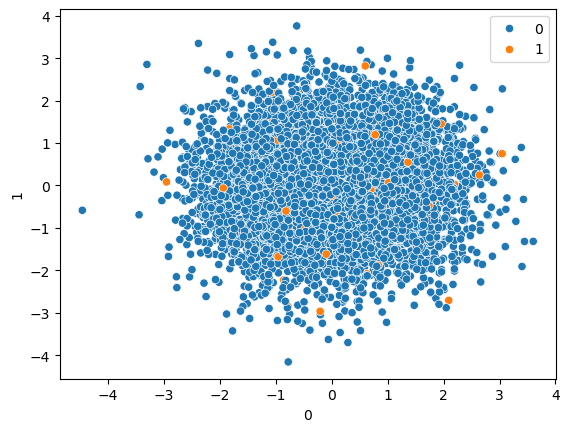

In [100]:
df = pd.DataFrame(x)

sns.scatterplot(
    x=df[0],
    y=df[1],
    hue=y
)

<Axes: xlabel='0', ylabel='1'>

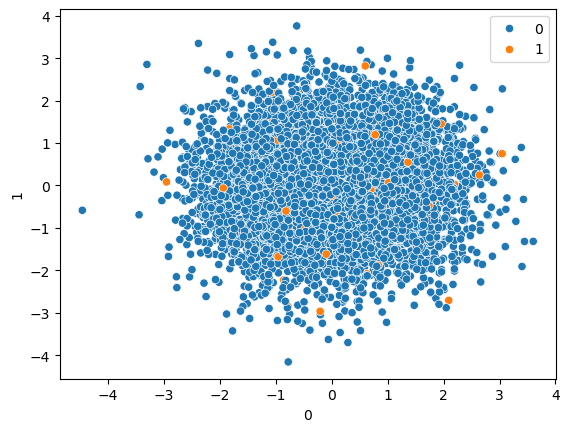

In [101]:
sns.scatterplot(
    x=pd.DataFrame(x)[0],
    y=pd.DataFrame(x)[1],
    hue=y
)